<>:241: SyntaxWarning: invalid escape sequence '\p'
<>:241: SyntaxWarning: invalid escape sequence '\p'
/var/folders/lr/j2hz1s0d0pn69_gzyyfbcdm00000gq/T/ipykernel_69200/291656194.py:241: SyntaxWarning: invalid escape sequence '\p'
  plt.text(0.1, 0.9*np.max(z4), 'FWHM = ' + str(np.around(result.params['wid'].value*2.355,2)) + '$\pm$'+ str(np.around(result.params['wid'].stderr*2.355,2))+'\"',size=20)
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set OBSGEO-B to   -36.965746 from OBSGEO-[XYZ].
Set OBSGEO-H to 1726065897.713 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


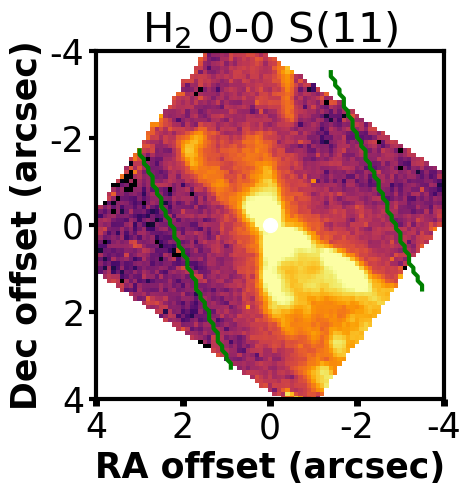

11.0
12.0
13.0


/var/folders/lr/j2hz1s0d0pn69_gzyyfbcdm00000gq/T/ipykernel_69200/291656194.py:241: SyntaxWarning: invalid escape sequence '\p'
  plt.text(0.1, 0.9*np.max(z4), 'FWHM = ' + str(np.around(result.params['wid'].value*2.355,2)) + '$\pm$'+ str(np.around(result.params['wid'].stderr*2.355,2))+'\"',size=20)


ValueError: 'xerr' (shape: (0,)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'x' (shape: (25,))

Error in callback <function _draw_all_if_interactive at 0x1693fbf60> (for post_execute), with arguments args (),kwargs {}:


ValueError: minvalue must be less than or equal to maxvalue

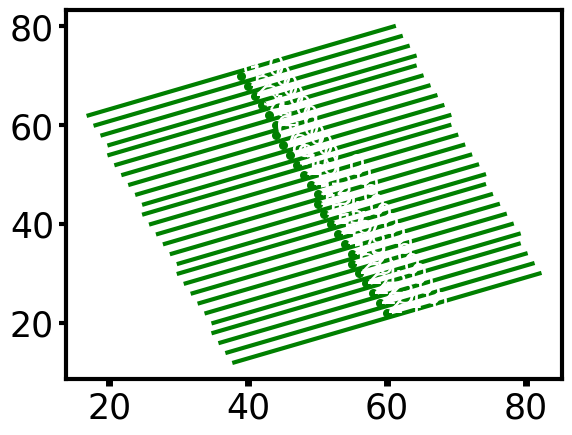

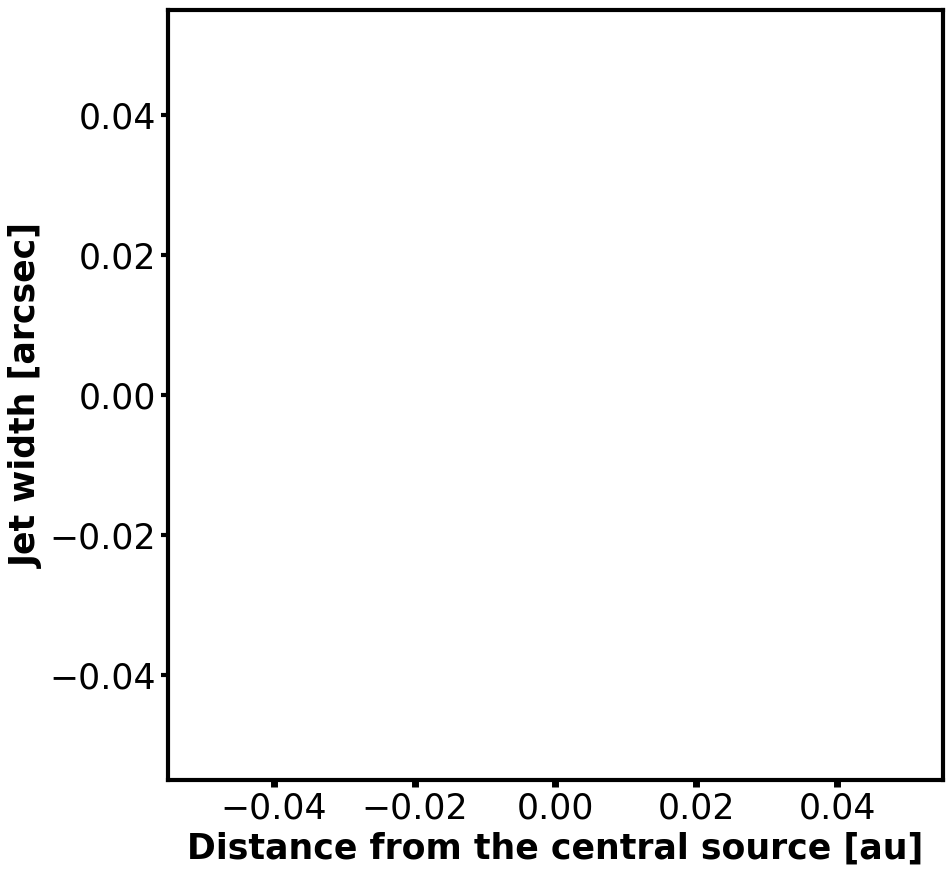

ValueError: minvalue must be less than or equal to maxvalue

<Figure size 640x480 with 1 Axes>

In [6]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Mon May 15 14:54:06 2023

@author: mnarang
"""

import astropy.units as u
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from astropy.wcs import WCS

from astropy.io import fits
from matplotlib.colors import LogNorm

plt.rcParams['font.size'] = 25
plt.rcParams['axes.labelsize'] = 25
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] =25
plt.rcParams['legend.fontsize'] = 25
plt.rcParams['figure.titlesize'] = 12
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['axes.linewidth'] = 3
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['xtick.major.width'] = 5
plt.rcParams['ytick.major.width'] = 3
plt.rcParams['xtick.minor.width'] = 5
plt.rcParams['ytick.minor.width'] = 3

def extract_along_line(fits_file, start_point, end_point):
    # Load FITS file
    with fits.open(fits_file) as hdul:
        data = hdul[0].data
    
    # Determine the line equation parameters
    x0, y0 = start_point
    x1, y1 = end_point
    dx = x1 - x0
    dy = y1 - y0
    
    # Compute the number of points along the line
    length = max(abs(dx), abs(dy))
    x = np.linspace(x0, x1, length+1)
    y = np.linspace(y0, y1, length+1)
    
    # Interpolate the coordinates to integer values
    xi = np.round(x).astype(int)
    yi = np.round(y).astype(int)
    
    # Extract the data along the line
    extracted_data = data[yi, xi]
    
    return extracted_data



def extract_perpendicular_line(fits_file, primary_start, primary_end, distance):
    # Load FITS file
    with fits.open(fits_file) as hdul:
        data = hdul[0].data
    
    # Determine the primary line equation parameters
    x0, y0 = primary_start
    x1, y1 = primary_end
    dx = x1 - x0
    dy = y1 - y0
    primary_length = max(abs(dx), abs(dy))
    primary_direction = np.array([dx, dy]) / primary_length
    
    # Determine the perpendicular line equation parameters
    perpendicular_direction = np.array([-primary_direction[1], primary_direction[0]])
    perpendicular_start = primary_start + (distance * perpendicular_direction)
    perpendicular_end = primary_end + (distance * perpendicular_direction)
    
    # Compute the number of points along the perpendicular line
    perpendicular_length = int(np.ceil(primary_length))
    x = np.linspace(perpendicular_start[0], perpendicular_end[0], perpendicular_length+1)
    y = np.linspace(perpendicular_start[1], perpendicular_end[1], perpendicular_length+1)
    
    # Interpolate the coordinates to integer values
    xi = np.round(x).astype(int)
    yi = np.round(y).astype(int)
    
    # Extract the data along the perpendicular line
    extracted_data = data[yi, xi]
    
    return extracted_data, xi, yi


# Example usage
fits_file = './I16253_lineimages/H200S11_4.18_linemap.fits'
start_point =  (39, 71) #in pixel units 
end_point =  (60, 21) #in pixel units

ab=22 #width of the cut you want to take in pixel units 

perpendicular_distance =ab

extracted_data, xi, yi = extract_perpendicular_line(fits_file, start_point, end_point, perpendicular_distance)
extracted_data, xi2, yi2 = extract_perpendicular_line(fits_file, start_point, end_point, -ab)
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

# Plotting both lines
with fits.open(fits_file) as hdul:
    data = hdul[0].data
hdu = fits.open(fits_file)[0]
wcs = WCS(hdu.header)
ps=hdu.header['CDELT1']*3600
cdt=wcs.wcs.cdelt[1]*3600

#plt.subplot(projection=wcs) 
plt.imshow(data, cmap='inferno', norm=LogNorm(vmin=1e-7,vmax=1e-5))
#plt.plot([start_point[0], end_point[0]], [start_point[1], end_point[1]], color='red', linewidth=1.5, label='Primary Line')
plt.plot(xi, yi, color='g', linewidth=3, label='Perpendicular Line')
plt.plot(xi2, yi2, color='g', linewidth=3, label='Perpendicular Line')

coord = SkyCoord('247.0901088 	-24.6066969', unit=(u.deg, u.deg)) # replace 'RA' and 'Dec' with the actual coordinates



# convert the coordinate to pixel coordinates using the WCS information
xa, ya = wcs.world_to_pixel(coord)
x, y = wcs.world_to_pixel(coord)
plt.tight_layout()

#plt.scatter(xa,ya,s=400,c='w',edgecolor='k')
xtick_positions=[]
ytick_positions=[]
xtick_labels=[]
ytick_labels=[]

i=-4
while (i<4.6):
    xtick_positions.append(xa+(i/np.abs(ps)))
    ytick_positions.append(ya+(i/np.abs(ps)))
    xtick_labels.append(np.round(-i,1))
    ytick_labels.append(np.round(-i,1))
    i+=2

plt.xticks(xtick_positions, xtick_labels)

# Set custom ticks and labels for the y-axis
plt.yticks(ytick_positions, ytick_labels)
    
plt.ylim(ya-(4/np.abs(ps)),ya+(4/np.abs(ps)))
plt.xlim(xa-(4/np.abs(ps)),xa+(4/np.abs(ps)))
    
plt.title('H$_2$ 0-0 S(11)')
plt.xlabel('RA offset (arcsec)')
plt.ylabel('Dec offset (arcsec)')

plt.scatter(xa,ya,c='w',s=100)

#plt.legend()
plt.show()

#%%

def gaussian_plus_line(x, amp, cen, wid, b):
    return amp * np.exp(-(x-cen)**2 / (2*wid**2)) + b

from lmfit import Model


ss=[]
x2=np.linspace(-ab,ab,120)

kk=0

qq=2 # the number of pixels you sum combine

gq=np.int32(np.round(qq/2))

XA=[]
YA=[]
while kk<len(xi):

    xx=[xi[kk],yi[kk]]
    xx2=[xi2[kk],yi2[kk]]
    zz=extract_along_line(fits_file,xx , xx2)
    
    
    aa=(xx[0],xx2[0])
    aa2=(xx[1],xx2[1])
    plt.plot(aa,aa2, color='g', linewidth=3, label='Perpendicular Line')
    if(kk+qq>len(xi)):
        break
    y3=(yi[kk+gq]+yi2[kk+gq])/2
    x3=(xi[kk+gq]+xi2[kk+gq])/2
    XA.append(x3)
    YA.append(y3)
    ss.append(np.sqrt((x3-x)**2 + (y3-y)**2)*((y-y3)/np.abs(y3-y))*cdt)
    
    
    plt.scatter(x3,y3,c='g',s=30)
    plt.text(x3,y3,kk/qq,c='w',size=20)
    kk=kk+qq
    
    #%%


plt.figure(figsize=(10,10))
cc=[]
ww=[]
ww_err=[] 
kk=0   
while kk<len(xi):
    zz=[]
    k2=0 
    if(kk+qq>len(xi)):
        break
    while(k2<qq):
        xx1=np.linspace(-ab,ab,2*ab+1)
        xy1=np.linspace(-ab,ab,100)*cdt
        xx=[xi[kk+k2],yi[kk+k2]]
        xx2=[xi2[kk+k2],yi2[kk+k2]]
        jj=extract_along_line(fits_file,xx , xx2)
        jj[np.isnan(jj)] = 0
        zz.append(jj)
        k2=k2+1 
    z4=np.median(zz,axis=0)
    plt.plot(-xx1*cdt,z4,'--o')
    
    #popt, pcov = curve_fit(gauss, xx1, z4)
   # er=np.sqrt(np.diag(pcov))
    #ym = gauss(x2, popt[0], popt[1], popt[2])
    if(kk/qq==11 or kk/qq==12 or kk/qq==13):
        print(kk/qq)
        model = Model(gaussian_plus_line)
        params = model.make_params(amp=np.max(z4)*1.0,cen=0.5, b=0)
        params.add('wid', value=1, min=0.1)
        result = model.fit(z4, params, x=xx1*cdt)
        y_eval = result.eval(x=xy1)
        plt.plot(-xy1, y_eval, label='Fit')
        plt.text(0.1, 0.9*np.max(z4), 'FWHM = ' + str(np.around(result.params['wid'].value*2.355,2)) + '$\pm$'+ str(np.around(result.params['wid'].stderr*2.355,2))+'\"',size=20)
        #plt.text(xx1[5]*cdt, 0.8*np.max(z4), 'Cen ' + str(np.around(result.params['cen'].value,2))+'arcsec' )
        #plt.plot(x2*cdt, ym, c='r', label='Best fit')
    #plt.text(xx1[5]*cdt, 0.95*np.max(z4), 'Box' + str(kk/qq))
    plt.xlim(-2.5,2.5)
    plt.xlabel('Cut (arcsec)')
    plt.ylabel('Flux density (ergs s$^{-1}$ cm$^{-2}$ sr$^{-1}$)')
    #cc.append(result.params['cen'].value)
    #ww.append(result.params['wid'].value*2.355)
    #ww_err.append(result.params['wid'].stderr*2.355)

        
    plt.savefig('box num_'+str(kk/qq)+'.png')
    plt.clf()

    kk=kk+qq


ss=np.array(ss)
ww=np.array(ww)

ww_err=np.array(ww_err)

XA=np.array(XA)
YA=np.array(YA)

#ss=ss[ww>0.1]
#XA=XA[ww>0.1]
#YA=YA[ww>0.1]

#ww_err=ww_err[ww>0]
#ww=ww[ww>0]
plt.errorbar(ss[ww/ww_err>3]*140,ww[ww/ww_err>3],yerr=ww_err[ww/ww_err>3],lw=3,ms=10,capsize=5)
i=0
while(i<len(XA)):
    #plt.text(ss[i]*140,1.1*ww[i],'bx = '+str(i))
    i=i+1
plt.xlabel("Distance from the central source [au]")
plt.ylabel("Jet width [arcsec]")
plt.savefig('Fig4b.png')

#%%

plt.figure()
plt.subplot(projection=wcs) 
plt.imshow(data, cmap='inferno',vmin=0.001)


ww1=ww/cdt
coord = SkyCoord('247.0901709 	-24.6065499', unit=(u.deg, u.deg)) # replace 'RA' and 'Dec' with the actual coordinates

# convert the coordinate to pixel coordinates using the WCS information
x, y = wcs.world_to_pixel(coord)
plt.scatter(x,y,c='w',s=100)
plt.errorbar(XA,YA,xerr=ww1)




plt.xlabel('RA')
plt.ylabel('Dec')
